Original columns: ['SEQN', 'age', 'bp_sys', 'bp_di', 'weight', 'height', 'bmi', 'waist', 'kcal', 'protein', 'sugar', 'carb', 'fat_total', 'fat_sat', 'fat_mon', 'fat_poly', 'hdl', 'glucose', 'triglycerides', 'gender', 'med_hbp', 'med_chol', 'extreme_bp', 'extreme_waist', 'extreme_hdl', 'extreme_tri', 'extreme_glu', 'metsyn']

Columns used for PCA: ['age', 'bp_sys', 'bp_di', 'weight', 'height', 'bmi', 'waist', 'kcal', 'protein', 'sugar', 'carb', 'fat_total', 'fat_sat', 'fat_mon', 'fat_poly', 'hdl', 'glucose', 'triglycerides']

Explained Variance Summary:
   Component  Individual_Variance_Ratio  Cumulative_Variance_Ratio
0        PC1                   0.330093                   0.330093
1        PC2                   0.193195                   0.523289
2        PC3                   0.091716                   0.615005
3        PC4                   0.072460                   0.687464
4        PC5                   0.058572                   0.746036
5        PC6                   0.057093

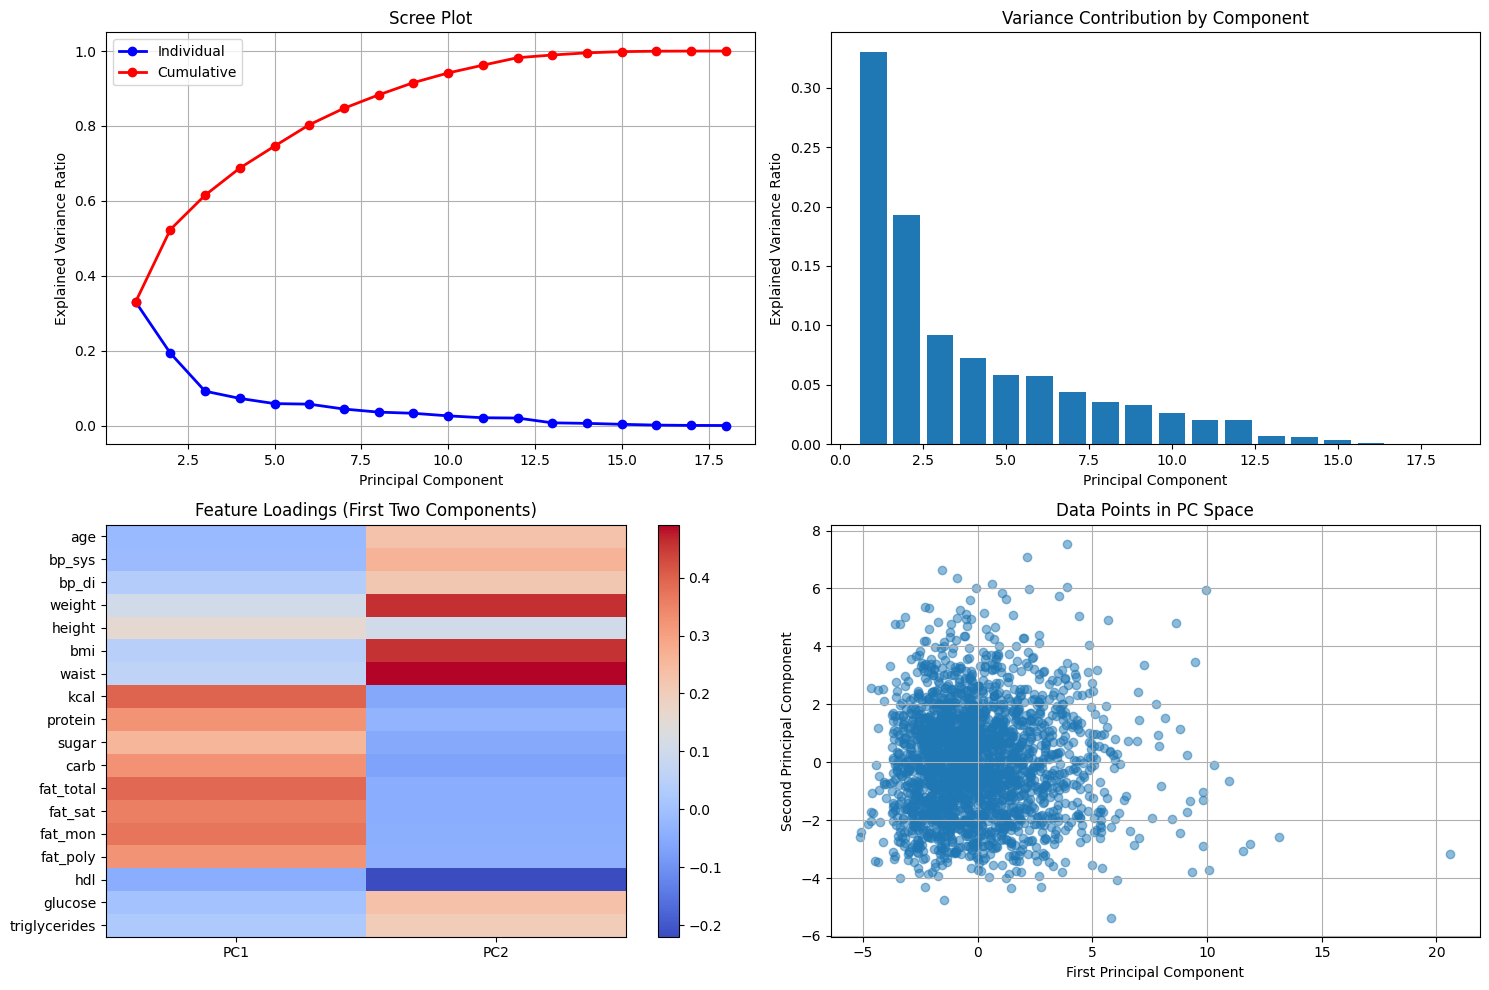

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def perform_pca_analysis(csv_path):
    """
    Perform PCA analysis on numeric columns only.
    
    Parameters:
    csv_path (str): Path to the CSV file
    
    Returns:
    tuple: (transformed_data, explained_variance_ratios, feature_names, pca_model)
    """
    # Read the dataset
    try:
        # Use index_col=0 to exclude the first unnamed column
        data = pd.read_csv(csv_path, index_col=0)
        print("Original columns:", data.columns.tolist())
    except Exception as e:
        raise Exception(f"Error reading CSV file: {str(e)}")
    
    # Identify truly numeric columns (exclude categorical and boolean)
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    
    # Exclude specific columns that are categorical or boolean
    cols_to_exclude = [
        'SEQN',  # ID column
        'sex',   # categorical
        'med_hbp', 'med_chol',  # medical flags
        'extreme_bp', 'extreme_waist', 'extreme_hdl', 
        'extreme_tri', 'extreme_glu', 'metsyn'  # boolean flags
    ]
    
    # Filter numeric columns
    numeric_cols = [col for col in numeric_cols if col not in cols_to_exclude]
    print("\nColumns used for PCA:", numeric_cols)
    
    # Prepare features
    X = data[numeric_cols]
    
    # Handle NaN values
    X = X.fillna(X.mean())
    
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Perform PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    # Create DataFrame with transformed data
    columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
    transformed_df = pd.DataFrame(X_pca, columns=columns)
    
    # Calculate explained variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
    
    # Create a summary of explained variance
    variance_df = pd.DataFrame({
        'Component': columns,
        'Individual_Variance_Ratio': explained_variance_ratio,
        'Cumulative_Variance_Ratio': cumulative_variance_ratio
    })
    
    return transformed_df, variance_df, numeric_cols, pca

def visualize_pca_results(transformed_df, variance_df, pca_model, feature_names):
    """
    Create visualizations for PCA results using matplotlib.
    """
    plt.style.use('default')
    fig = plt.figure(figsize=(15, 10))
    components = range(1, len(variance_df) + 1) 

    
    # 1. Scree plot
    plt.subplot(2, 2, 1)
    plt.plot(components, variance_df['Individual_Variance_Ratio'], 'bo-', linewidth=2)
    plt.plot(components, variance_df['Cumulative_Variance_Ratio'], 'ro-', linewidth=2)
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    plt.title('Scree Plot')
    plt.legend(['Individual', 'Cumulative'])
    plt.grid(True)
    
    # 2. Variance Contribution Plot
    plt.subplot(2, 2, 2)
    plt.bar(components, variance_df['Individual_Variance_Ratio'])
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    plt.title('Variance Contribution by Component')
    
    # 3. Feature loadings heatmap
    plt.subplot(2, 2, 3)
    loadings = pd.DataFrame(
        pca_model.components_[:2, :].T,  # Only first two components
        index=feature_names,
        columns=['PC1', 'PC2']
    )
    im = plt.imshow(loadings, aspect='auto', cmap='coolwarm')
    plt.colorbar(im)
    plt.title('Feature Loadings (First Two Components)')
    plt.yticks(range(len(feature_names)), feature_names)
    plt.xticks([0, 1], ['PC1', 'PC2'])
    
    # 4. PC1 vs PC2 scatter plot
    plt.subplot(2, 2, 4)
    plt.scatter(transformed_df['PC1'], transformed_df['PC2'], alpha=0.5)
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title('Data Points in PC Space')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
def analyze_pca(csv_path):
    """
    Perform complete PCA analysis on numeric data only.
    """
    # Perform PCA
    transformed_data, variance_df, feature_names, pca_model = perform_pca_analysis(csv_path)
    
    # Print numerical results
    print("\nExplained Variance Summary:")
    print(variance_df)
    
    # Print feature loadings for first two components
    loadings = pd.DataFrame(
        pca_model.components_.T,
        columns=[f'PC{i+1}' for i in range(pca_model.components_.shape[0])],
        index=feature_names
    )
    
    print("\nFeature Loadings (first two components):")
    print(loadings[['PC1', 'PC2']])
    
    # Find most important features for first two components
    print("\nTop Contributing Features:")
    for pc in ['PC1', 'PC2']:
        print(f"\nTop 5 features for {pc}:")
        top_features = loadings[pc].abs().sort_values(ascending=False).head(5)
        for feature, loading in top_features.items():
            print(f"{feature}: {loading:.4f}")
    
    # Create visualizations
    visualize_pca_results(transformed_data, variance_df, pca_model, feature_names)
    
    return transformed_data, variance_df, loadings

# Run the analysis
if __name__ == "__main__":
    analyze_pca('Nutrition Data from NHANES.csv')